In [203]:
import pandas as pd
import numpy as np
import itertools
import random
from collections import defaultdict

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
import pickle

In [204]:
df = pd.read_csv("realistic_csao_dataset_60k.csv")
df = df.sort_values(["order_id", "timestamp"])

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (156110, 8)


,order_id,user_id,restaurant_id,item_id,item_name,category,price,timestamp
0,1,5239,58,9,Chicken Wrap,Main_Course,199,2025-12-01 02:23:39.614379
1,1,5239,58,13,Chicken Nuggets,Starter,179,2025-12-01 02:23:39.614379
2,1,5239,58,23,Ice Cream,Dessert,99,2025-12-01 02:23:39.614379
3,2,840,347,1,Margherita Pizza,Main_Course,249,2026-02-04 05:45:39.614379
4,2,840,347,12,Garlic Bread,Starter,149,2026-02-04 05:45:39.614379


In [205]:
training_rows = []

for order_id, group in df.groupby("order_id"):
    items = group["item_id"].tolist()
    user = group["user_id"].iloc[0]
    restaurant = group["restaurant_id"].iloc[0]

    for i in range(1, len(items)):
        cart_items = items[:i]
        next_item = items[i]

        training_rows.append({
            "user_id": user,
            "restaurant_id": restaurant,
            "cart_size": len(cart_items),
            "last_item": cart_items[-1],
            "candidate_item": next_item,
            "label": 1
        })

positive_df = pd.DataFrame(training_rows)
print("Positive samples:", positive_df.shape)
positive_df.head()

Positive samples: (96110, 6)


,user_id,restaurant_id,cart_size,last_item,candidate_item,label
0,5239,58,1,9,13,1
1,5239,58,2,13,23,1
2,840,347,1,1,12,1
3,245,48,1,5,19,1
4,5866,333,1,2,17,1


In [206]:
all_items = df["item_id"].unique()
negative_rows = []

for _, row in positive_df.iterrows():
    negatives = random.sample(list(all_items), 3)

    for item in negatives:
        negative_rows.append({
            "user_id": row["user_id"],
            "restaurant_id": row["restaurant_id"],
            "cart_size": row["cart_size"],
            "last_item": row["last_item"],
            "candidate_item": item,
            "label": 0
        })

negative_df = pd.DataFrame(negative_rows)

final_df = pd.concat([positive_df, negative_df], ignore_index=True)

print("Final dataset shape:", final_df.shape)

Final dataset shape: (384440, 6)


In [207]:
item_features = df[["item_id", "category", "price"]].drop_duplicates()

final_df = final_df.merge(
    item_features,
    left_on="candidate_item",
    right_on="item_id",
    how="left"
)

final_df.drop("item_id", axis=1, inplace=True)

In [208]:
co_occurrence = defaultdict(int)

for order_id, group in df.groupby("order_id"):
    items = group["item_id"].tolist()
    for item1, item2 in itertools.permutations(items, 2):
        co_occurrence[(item1, item2)] += 1

item_counts = df["item_id"].value_counts().to_dict()

def get_cooccurrence_score(last_item, candidate_item):
    pair_count = co_occurrence.get((last_item, candidate_item), 0)
    last_count = item_counts.get(last_item, 1)
    return pair_count / last_count

final_df["cooccurrence_score"] = final_df.apply(
    lambda row: get_cooccurrence_score(row["last_item"], row["candidate_item"]),
    axis=1
)

In [209]:
final_df = pd.get_dummies(final_df, columns=["category"], drop_first=True)

print("Final features:", final_df.columns)

Final features: Index(['user_id', 'restaurant_id', 'cart_size', 'last_item', 'candidate_item',
       'label', 'price', 'cooccurrence_score', 'category_Dessert',
       'category_Main_Course', 'category_Starter'],
      dtype='object')


In [210]:
X = final_df.drop("label", axis=1)
y = final_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:

model = LGBMClassifier(
    n_estimators=900,
    learning_rate=0.05,
    num_leaves=40,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)
import pickle

pickle.dump(model, open("model.pkl", "wb"))
print("Model saved successfully")

preds = model.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, preds)
print("AUC:", auc)

[LightGBM] [Info] Number of positive: 76862, number of negative: 230690
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001960 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 844
[LightGBM] [Info] Number of data points in the train set: 307552, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Model saved successfully
AUC: 0.8481177510335888


In [212]:
# Item popularity
item_popularity = df["item_id"].value_counts().to_dict()

final_df["candidate_popularity"] = final_df["candidate_item"].map(item_popularity)

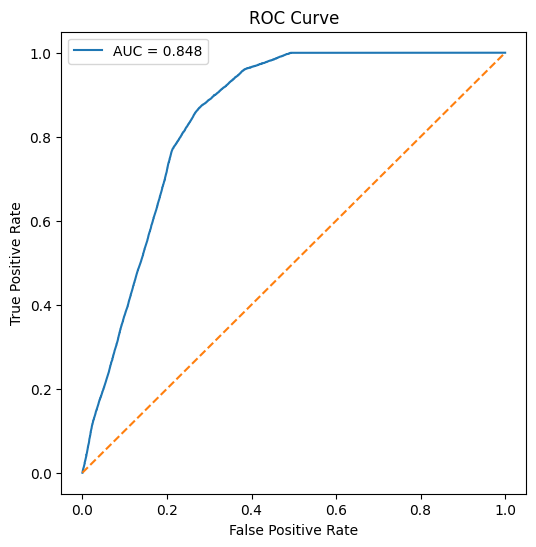

In [213]:
fpr, tpr, _ = roc_curve(y_test, preds)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

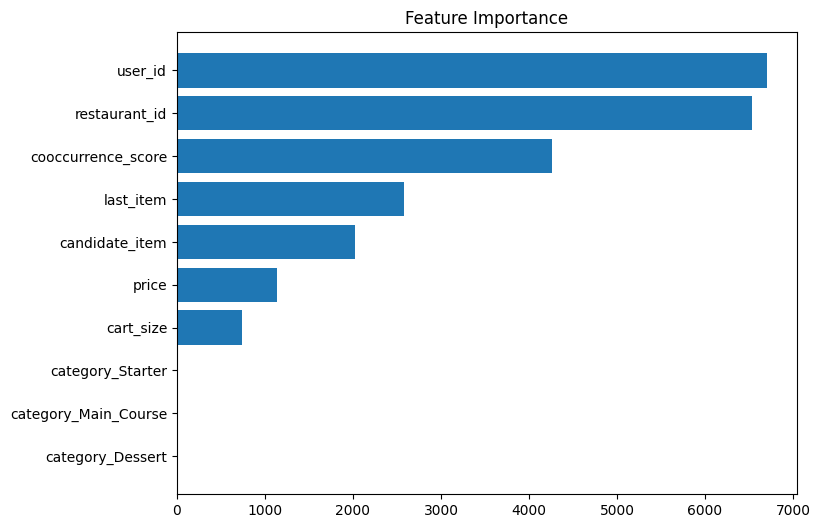

In [214]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

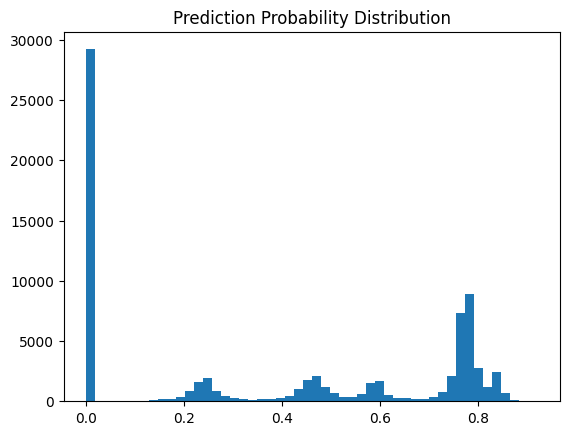

In [215]:
plt.hist(preds, bins=50)
plt.title("Prediction Probability Distribution")
plt.show()

In [216]:
def precision_at_k(y_true, y_scores, k=8):
    idx = np.argsort(y_scores)[::-1][:k]
    return y_true.iloc[idx].sum() / k

print("Precision@8:", precision_at_k(y_test.reset_index(drop=True), preds, 8))

Precision@8: 0.625


In [217]:
model = pickle.load(open(r"C:\Users\saxen\Desktop\zamoto\model.pkl", "rb"))

In [218]:
import os
print(os.listdir())

['app.py', 'main.ipynb', 'model.pkl', 'realistic_csao_dataset_60k.csv']
